# Interprétabilité du Modèle (SHAP)
Ce notebook utilise SHAP (SHapley Additive exPlanations) pour comprendre les décisions du modèle XGBoost.

In [8]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
from sklearn.model_selection import train_test_split

# 1. Chargement du Pipeline et du Modèle "Expert"
# Assure-toi que ton fichier s'appelle bien 02_Preprocessing.py
preprocessing = importlib.import_module("02_Preprocessing")
PipelineManager = preprocessing.ChurnExpertPipeline 

# Chargement des artefacts sauvegardés
model = joblib.load('outputs/model_xgboost_expert.joblib')
preprocessor = joblib.load('outputs/preprocessor.joblib')
feature_names = joblib.load('outputs/feature_names.joblib')

# 2. Préparation des données
manager = PipelineManager('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_full = manager.load_and_prepare()

X = df_full.drop('Churn', axis=1)
y = (df_full['Churn'] == 'Yes').astype(int)

# On refait le split EXACT (même seed 42 et stratify)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# TRANSFORMATION : On passe X_train_raw explicitement au lieu de "_" 
# pour éviter l'erreur de déballage (unpacking)
X_train_df, X_test_df = manager.process_to_df(X_train_raw, X_test_raw)

# 3. Calcul de SHAP
# On utilise TreeExplainer car c'est un modèle XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)


## 1. Summary Plot (Global Explanation)
Visualisation de l'importance globale des features.

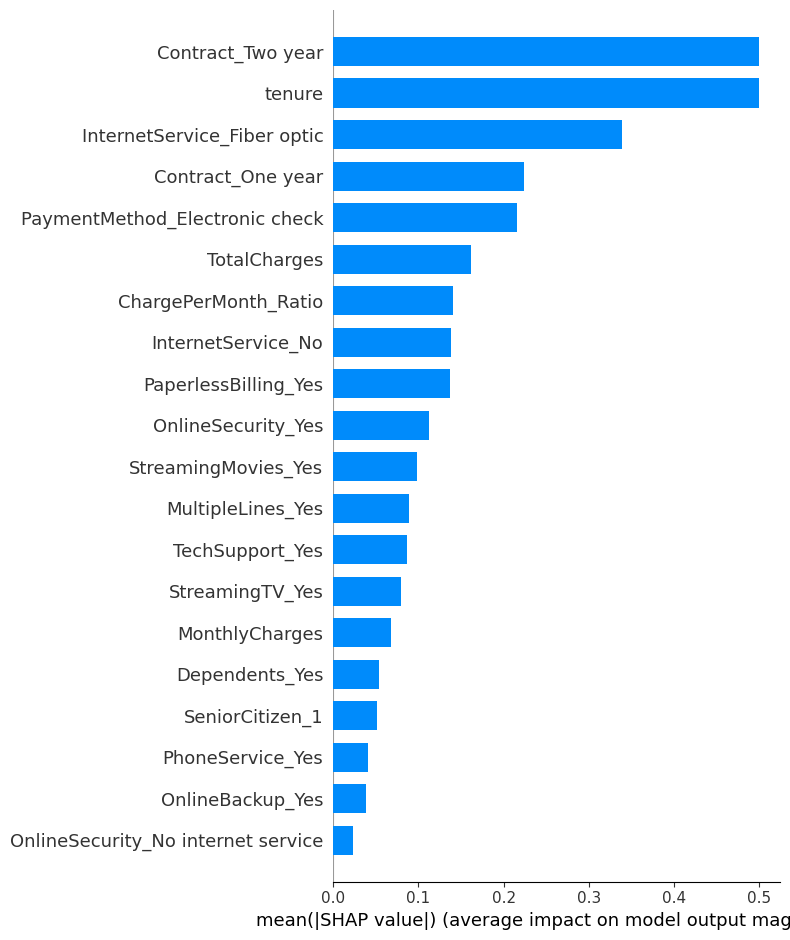

In [9]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

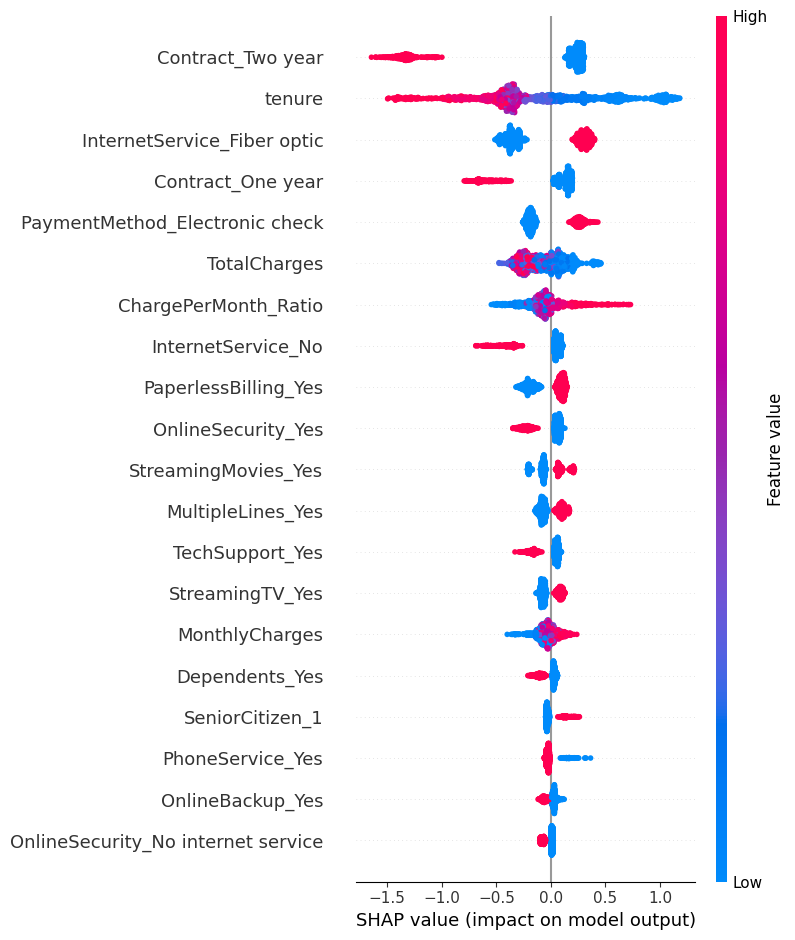

In [10]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df)

**Interprétation :** Les variables les plus discriminantes sont le type de contrat (Month-to-month), la tenure et le mode de paiement. On voit clairement qu'une tenure faible augmente fortement la probabilité de churn.

## 2. Local Explanation (Individual Prediction)
Explication d'une prédiction spécifique.

In [11]:
def explain_prediction(index):
    shap.initjs()
    print(f"Explication pour le client index {index}")
    print(f"Probabilité de churn : {model.predict_proba(X_test_df.iloc[[index]])[0][1]:.2f}")
    return shap.force_plot(explainer.expected_value, shap_values[index], X_test_df.iloc[index])

# Exemple pour le premier client du set de test
explain_prediction(0)

Explication pour le client index 0
Probabilité de churn : 0.06
